In [9]:
import tidy3d as td
import tidy3d.web as web
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# Parameters
wavelength = 0.729 # um
w0 = 2.5  # Beam waist
z_prop = 100.0           # Propagation distance
sim_size_x = 40.0        # Width of simulation
sim_size_z = z_prop + 5.0 # Length of simulation
source_size = 18.0

# Grid and Frequency
f0 = td.C_0 / wavelength
run_time = 2e-12

In [11]:
# 1. Define Gaussian Source
# Placed at z=2, propagating in +z direction
gaussian_beam = td.GaussianBeam(
    center=(0, 0, -(sim_size_z/2) + w0),
    size=(source_size, td.inf, 0),
    source_time=td.GaussianPulse(freq0=f0, fwidth=f0/10),
    pol_angle=0,
    direction='+',
    waist_radius=w0,
    waist_distance=0.0,
)

# 2. Monitors
# Field monitor for the 2D plane (Side Slice)
monitor_xz = td.FieldMonitor(
    center=(0, 0, 0),
    size=(sim_size_x, td.inf, sim_size_z),
    freqs=[f0],
    name="xz_profile"
)

# Field monitor at the end (Head-on View)
monitor_end = td.FieldMonitor(
    center=(0, 0, (sim_size_z/2) - w0),
    size=(td.inf, td.inf, 0),
    freqs=[f0],
    name="end_profile"
)

In [12]:
# 3. Simulation Setup
sim = td.Simulation(
    size=(sim_size_x, 0, sim_size_z),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=15),
    sources=[gaussian_beam],
    monitors=[monitor_xz, monitor_end],
    run_time=run_time,
    boundary_spec=td.BoundarySpec(
        x=td.Boundary.pml(),
        y=td.Boundary.periodic(),
        z=td.Boundary.pml(),
    )
)

In [13]:
sim.plot_3d()

In [14]:
# 4. Run and Plot
job = web.Job(simulation=sim, task_name="gaussian_prop")
print(f"Simulation cost is {web.estimate_cost(job.task_id)}")
data = job.run(path="data/simulation_data.hdf5")

09:19:59 PST Created task 'gaussian_prop' with resource_id                      
             'fdve-36ba6dda-43a9-42ba-ba3f-bf835cfe25ad' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=771241;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ba6dda-43a9-42ba-ba3f-bf835cfe25ad\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=443389;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ba6dda-43a9-42ba-ba3f-bf835cfe25ad\taskId]8;;\]8;id=771241;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ba6dda-43a9-42ba-ba3f-bf835cfe25ad\=]8;;\]8;id=143131;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ba6dda-43a9-42ba-ba3f-bf835cfe25ad\fdve]8;;\]8;id=771241;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ba6dda-43a9-42ba-ba3f-bf835cfe25ad\-36ba6dda-43a]8;;\
             ]8;id=771241;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ba6dda-43a9-42ba-ba3f-bf835cfe25ad\9-42ba-ba3f-bf835cfe25ad']8;;\.

             Task folder: ]8;id=189639;https://tidy3d.simulation.cloud/folders/folder-c1256dcf-ea12-4d61-b02e-44feec7479e6\'default']8;;\.

Output()

09:20:00 PST Estimated FlexCredit cost: 0.025. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

Output()

09:20:17 PST status = success

09:20:19 PST View simulation result at                                          
             ]8;id=783095;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ba6dda-43a9-42ba-ba3f-bf835cfe25ad\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=516967;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ba6dda-43a9-42ba-ba3f-bf835cfe25ad\taskId]8;;\]8;id=783095;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ba6dda-43a9-42ba-ba3f-bf835cfe25ad\=]8;;\]8;id=417083;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ba6dda-43a9-42ba-ba3f-bf835cfe25ad\fdve]8;;\]8;id=783095;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ba6dda-43a9-42ba-ba3f-bf835cfe25ad\-36ba6dda-43a]8;;\
             ]8;id=783095;https://tidy3d.simulation.cloud/workbench?taskId=fdve-36ba6dda-43a9-42ba-ba3f-bf835cfe25ad\9-42ba-ba3f-bf835cfe25ad']8;;\.

Output()

09:20:26 PST Loading simulation from data/simulation_data.hdf5

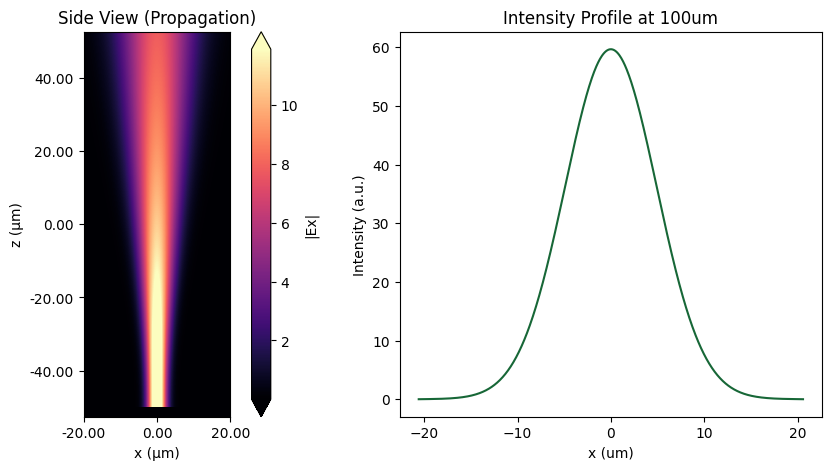

In [15]:
# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Side Slice (XZ)
data.plot_field("xz_profile", "Ex", val="abs", ax=ax[0])
ax[0].set_title("Side View (Propagation)")

# Plot Head-on Profile at 100um
field_end = data["end_profile"].Ex.sel(f=f0, method="nearest").squeeze()

x_axis = field_end.x
intensity = np.abs(field_end)**2

ax[1].plot(x_axis, intensity)
ax[1].set_title("Intensity Profile at 100um")
ax[1].set_xlabel("x (um)")
ax[1].set_ylabel("Intensity (a.u.)")
plt.show()

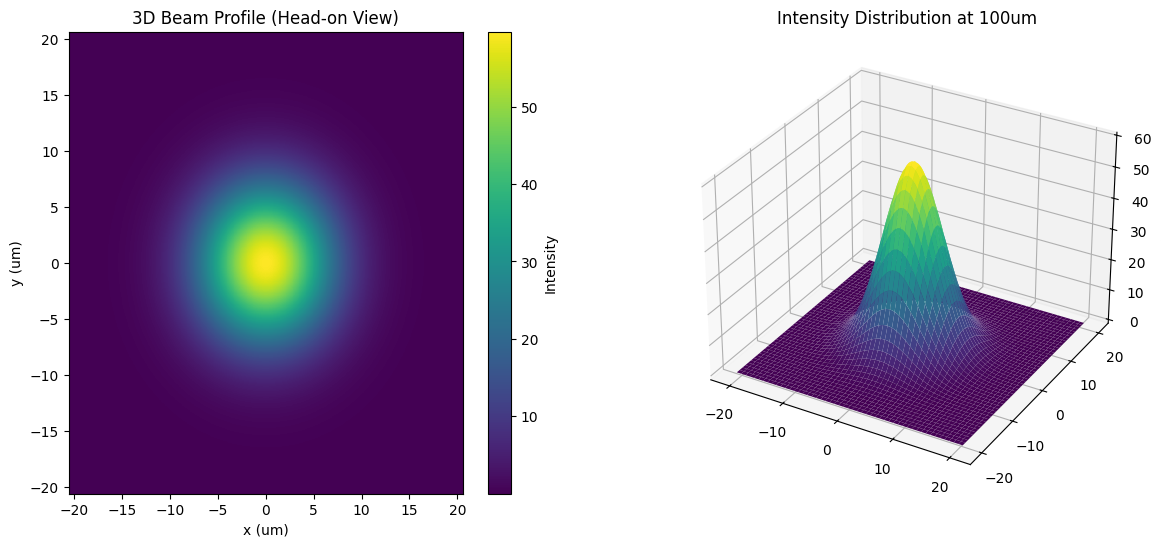

In [16]:
# 1. Extract and clean the 1D data
field_end = data["end_profile"].Ex.sel(f=f0, method="nearest").squeeze()
x_axis = field_end.x.values
intensity_1d = np.abs(field_end).values**2

# 2. Create a 2D grid for X and Y
# We assume the beam is symmetric, so we use the x_axis for both dimensions
X, Y = np.meshgrid(x_axis, x_axis)
R = np.sqrt(X**2 + Y**2)

# 3. Interpolate the 1D intensity onto the 2D grid
# This maps our simulation result into a full 3D head-on view
intensity_2d = np.interp(R, x_axis[len(x_axis)//2:], intensity_1d[len(intensity_1d)//2:])

# 4. Plotting
fig = plt.figure(figsize=(14, 6))

# Subplot 1: 2D Heatmap (Head-on)
ax1 = fig.add_subplot(1, 2, 1)
im = ax1.pcolormesh(X, Y, intensity_2d, shading='auto', cmap='viridis')
ax1.set_title("3D Beam Profile (Head-on View)")
ax1.set_xlabel("x (um)")
ax1.set_ylabel("y (um)")
plt.colorbar(im, ax=ax1, label='Intensity')

# Subplot 2: 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(X, Y, intensity_2d, cmap='viridis', edgecolor='none')
ax2.set_title("Intensity Distribution at 100um")
ax2.set_zlabel("Intensity")
plt.show()